# Regression Using Pytorch

## Bal Krishna Dhakal(ACE080BCT018)

## PyTorch for Regression

PyTorch is an open-source deep learning framework used for building and training machine learning models. PyTorch is used to predict continuous numerical values by learning the relationship between input features and target outputs. It provides modules such as torch.nn for defining neural networks and torch.optim for optimizing model parameters during training.

In [3]:
# Import PyTorch and matplotlib
import torch
import matplotlib.pyplot as plt

# Check PyTorch version
torch.__version__

'2.12.0+cpu'

In [4]:
# Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cpu


## 1. Data Preparation

Data preparation is the process of organizing and converting raw data into a suitable format for model training. In PyTorch, input features and target values are converted into tensors, which are the fundamental data structures used by the framework. Proper data preparation ensures efficient learning and improves model performance.

In [ ]:
import pandas as pd
import torch
# df = pd.read_csv(r'assignment-data2 (1).csv')
# df = pd.read_csv(r'linear-regression-data1 (1).csv')
# df = pd.read_csv(r'binary_classification_moons.csv')
df = pd.read_csv(r'assignment-data.csv')
df.head(6)

,x,y
0,0.0,2.00
1,0.2,2.12
2,0.4,2.48
3,0.6,3.08
4,0.8,3.92
5,1.0,5.00


In [79]:

# convert to torch tensors for use in the notebook
X = torch.tensor(df['x'].values, dtype=torch.float32).unsqueeze(1)
y = torch.tensor(df['y'].values, dtype=torch.float32).unsqueeze(1)
print(X.shape)
print(y.shape)

torch.Size([50, 1])
torch.Size([50, 1])


In [80]:

# Split data
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

In [81]:
def plot_predictions(train_data=X_train, 
                     train_labels=y_train, 
                     test_data=X_test, 
                     test_labels=y_test, 
                     predictions=None):
  """
  Plots training data, test data and compares predictions.
  """
  plt.figure(figsize=(10, 7))

  # Plot training data in blue
  plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")
  
  # Plot test data in green
  plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

  if predictions is not None:
    # Plot the predictions in red (predictions were made on the test data)
    plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

  # Show the legend
  plt.legend(prop={"size": 14});

In [82]:
import matplotlib.pyplot as plt

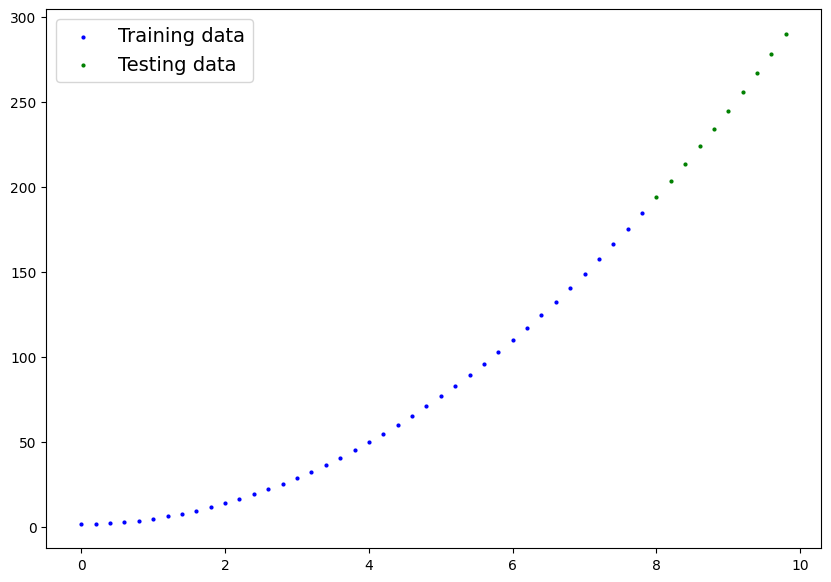

In [83]:

# Note: If you've reset your runtime, this function won't work, 
# you'll have to rerun the cell above where it's instantiated.
plot_predictions(X_train, y_train, X_test, y_test)

## Algorithm Selection

In [84]:
import torch.nn as nn

In [85]:
# Create a Linear Regression model class
class LinearRegressionModel(nn.Module): # <- almost everything in PyTorch is a nn.Module (think of this as neural network lego blocks)
    def __init__(self):
        super().__init__() 
        self.weights = nn.Parameter(torch.randn(1, # <- start with random weights (this will get adjusted as the model learns)
                                                dtype=torch.float), # <- PyTorch loves float32 by default
                                   requires_grad=True) # <- can we update this value with gradient descent?)

        self.bias = nn.Parameter(torch.randn(1, # <- start with random bias (this will get adjusted as the model learns)
                                            dtype=torch.float), # <- PyTorch loves float32 by default
                                requires_grad=True) # <- can we update this value with gradient descent?))

    # Forward defines the computation in the model
    def forward(self, x: torch.Tensor) -> torch.Tensor: # <- "x" is the input data (e.g. training/testing features)
        return self.weights * x + self.bias # <- this is the linear regression formula (y = m*x + b)

In [86]:
# Set manual seed since nn.Parameter are randomly initialized
torch.manual_seed(42)

# Create an instance of the model (this is a subclass of nn.Module that contains nn.Parameter(s))
model_0 = LinearRegressionModel()

# Check the nn.Parameter(s) within the nn.Module subclass we created
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [87]:
print(model_0.weights.dtype)
print(model_0.bias.dtype)

torch.float32
torch.float32


In [88]:
# Make predictions with model
with torch.inference_mode(): 
    y_preds = model_0(X_test)

# Note: in older PyTorch code you might also see torch.no_grad()
# with torch.no_grad():
#   y_preds = model_0(X_test)

y_preds[:5]

tensor([[2.8223],
        [2.8897],
        [2.9570],
        [3.0243],
        [3.0917]])

In [90]:

# Check the predictions
print(f"Number of testing samples: {len(X_test)}") 
print(f"Number of predictions made: {len(y_preds)}")
print(f"Predicted values:\n{y_preds}")

Number of testing samples: 10
Number of predictions made: 10
Predicted values:
tensor([[2.8223],
        [2.8897],
        [2.9570],
        [3.0243],
        [3.0917],
        [3.1590],
        [3.2264],
        [3.2937],
        [3.3610],
        [3.4284]])


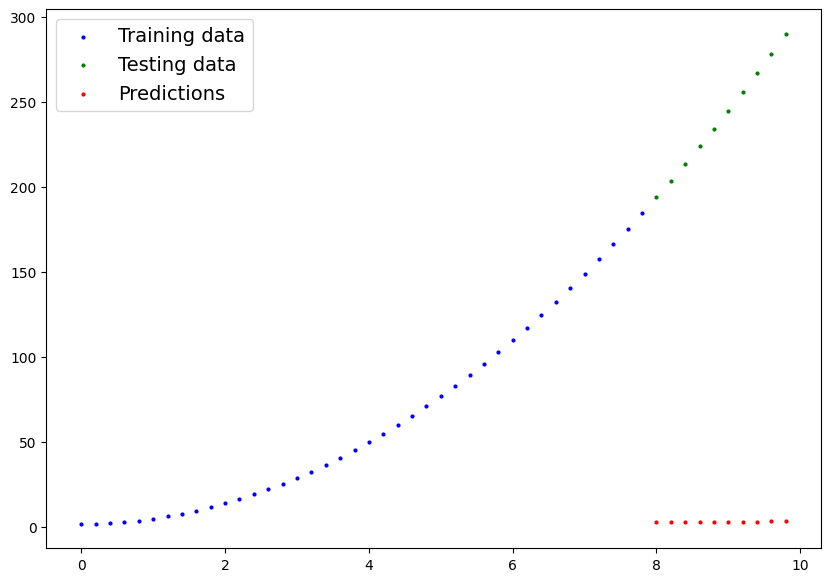

In [91]:
plot_predictions(predictions=y_preds)

## Loss Function Selection


A loss function measures the difference between the model's predicted values and the actual target values. During training, the objective is to minimize this loss so that the model makes more accurate predictions.

Mean Absolute Error (MAE) is the average absolute difference between true values (y_i) and predictions (ŷ_i).

$$
MAE = \frac{1}{n}\sum_{i=1}^{n} \left| y_i - \hat{y}_i \right|
$$

where:

- $y_i$ = actual value
- $\hat{y}_i$ = predicted value
- $n$ = number of samples


In [92]:
# Loss Function Selection
from torch import nn # nn contains all of PyTorch's building blocks for neural networks

# Create the loss function
loss_fn = nn.L1Loss() # MAE loss is same as L1Loss

# Create the optimizer
optimizer = torch.optim.SGD(
                    params=model_0.parameters(), # parameters of target model to optimize
                    lr=0.01) # learning rate (how much the optimizer should change parameters at each step, higher=more (less stable), lower=less (might take a long time))

## Model Training

Model training is the process of teaching the neural network to learn patterns from the data. During each training iteration, the model performs a forward pass to generate predictions, computes the loss, performs backpropagation to calculate gradients, and updates the model parameters using an optimizer.


## Model Prediction

After training, the model is used to make predictions on unseen data. The trained model applies the learned relationship between inputs and outputs to estimate target values for new samples. These predictions can then be compared with actual values to assess model performance.

## Model Evaluation

Model evaluation measures how well the trained model performs on unseen data. The model's predictions are compared with actual target values using evaluation metrics and visual inspection.


In [94]:
torch.manual_seed(42)

# Set the number of epochs (how many times the model will pass over the training data)
epochs = 200

# Create empty loss lists to track values
train_loss_values = []
test_loss_values = []
epoch_count = []

for epoch in range(epochs):
    ### Training

    # Put model in training mode (this is the default state of a model)
    model_0.train()

    # 1. Forward pass on train data using the forward() method inside 
    y_pred = model_0(X_train)
    # print(y_pred)

    # 2. Calculate the loss (how different are our models predictions to the ground truth)
    loss = loss_fn(y_pred, y_train)

    # 3. Zero grad of the optimizer
    optimizer.zero_grad()

    # 4. Loss backwards
    loss.backward()

    # 5. Progress the optimizer
    optimizer.step()

    ### Testing

    # Put the model in evaluation mode
    model_0.eval()

    with torch.inference_mode():
      # 1. Forward pass on test data
      test_pred = model_0(X_test)

      # 2. Calculate loss on test data
      test_loss = loss_fn(test_pred, y_test.type(torch.float)) # predictions come in torch.float datatype, so comparisons need to be done with tensors of the same type

      # Print out what's happening every 10 epochs
      if epoch % 10 == 0:
            epoch_count.append(epoch)
            train_loss_values.append(loss.detach().numpy())
            test_loss_values.append(test_loss.detach().numpy())
            print(f"Epoch: {epoch} | MAE Train Loss: {loss} | MAE Test Loss: {test_loss} ")

Epoch: 0 | MAE Train Loss: 14.699758529663086 | MAE Test Loss: 83.01146697998047 
Epoch: 10 | MAE Train Loss: 14.694534301757812 | MAE Test Loss: 82.9983139038086 
Epoch: 20 | MAE Train Loss: 14.689311027526855 | MAE Test Loss: 82.98516845703125 
Epoch: 30 | MAE Train Loss: 14.684086799621582 | MAE Test Loss: 82.97201538085938 
Epoch: 40 | MAE Train Loss: 14.678863525390625 | MAE Test Loss: 82.9588623046875 
Epoch: 50 | MAE Train Loss: 14.673639297485352 | MAE Test Loss: 82.94572448730469 
Epoch: 60 | MAE Train Loss: 14.668414115905762 | MAE Test Loss: 82.93256378173828 
Epoch: 70 | MAE Train Loss: 14.663192749023438 | MAE Test Loss: 82.9194107055664 
Epoch: 80 | MAE Train Loss: 14.657968521118164 | MAE Test Loss: 82.90625762939453 
Epoch: 90 | MAE Train Loss: 14.652743339538574 | MAE Test Loss: 82.89310455322266 
Epoch: 100 | MAE Train Loss: 14.647520065307617 | MAE Test Loss: 82.87996673583984 
Epoch: 110 | MAE Train Loss: 14.642295837402344 | MAE Test Loss: 82.86681365966797 
Epoch:

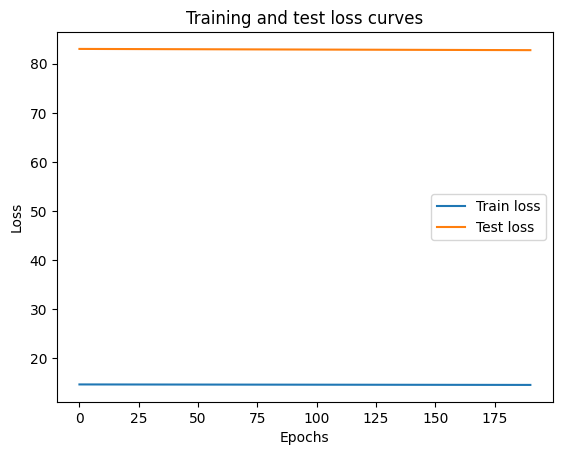

In [95]:
# Plot the loss curves
plt.plot(epoch_count, train_loss_values, label="Train loss")
plt.plot(epoch_count, test_loss_values, label="Test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend();

In [96]:
# Find our model's learned parameters
print("The model learned the following values for weights and bias:")
print(model_0.state_dict())
print("\nAnd the original values for weights and bias are:")
print(f"weights: 0.7, bias: 0.3")

The model learned the following values for weights and bias:
OrderedDict({'weights': tensor([18.7273]), 'bias': tensor([-8.7898])})

And the original values for weights and bias are:
weights: 0.7, bias: 0.3


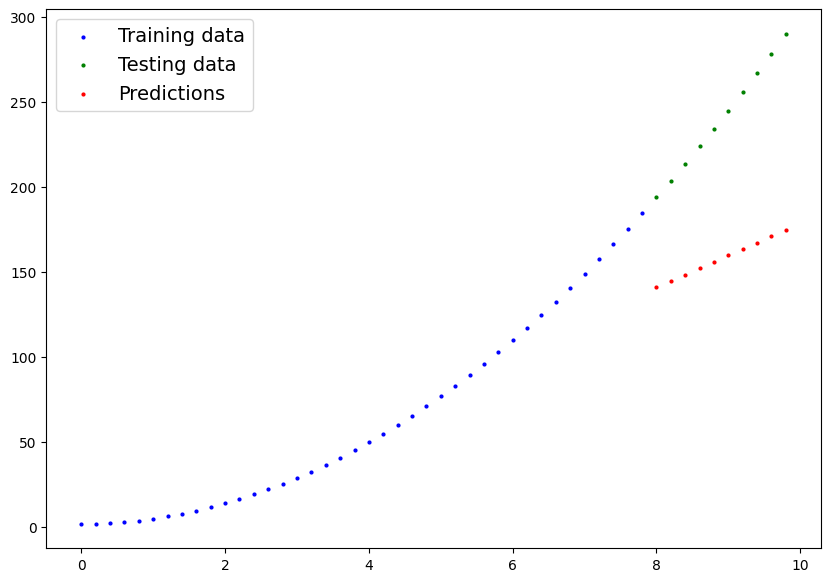

In [97]:
# 1. Set the model in evaluation mode
model_0.eval()

# 2. Setup the inference mode context manager
with torch.inference_mode():
  # 3. Make sure the calculations are done with the model and data on the same device
  # in our case, we haven't setup device-agnostic code yet so our data and model are
  # on the CPU by default.
  # model_0.to(device)
  # X_test = X_test.to(device)
  y_preds = model_0(X_test)
plot_predictions(predictions=y_preds)

## Discussion and Conclusion

In this lab, a Linear Regression model was implemented using PyTorch to predict continuous values from given input features. The model was built using tensors and trained with an appropriate loss function (Mean Absolute Error) along with an optimization algorithm based on gradient descent to update the model parameters.

During the training process, the loss consistently decreased over iterations, indicating that the model was effectively learning the underlying relationship between inputs and outputs. This gradual reduction in error confirmed the correctness of the training pipeline and the suitability of the chosen hyperparameters.

Overall, the experiment successfully demonstrated how regression problems can be solved using PyTorch. It provided hands-on experience with key machine learning concepts such as tensor operations, model training workflow, loss computation, and optimization techniques. The results highlight the efficiency and flexibility of PyTorch in building and training machine learning models for real-world predictive tasks.
